In [6]:
analysis_year = 2024
traffic_rel_path = "Data/Trafficdata/traffic_24.csv"

In [7]:
from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / traffic_rel_path).exists() and (project_root.parent / traffic_rel_path).exists():
    project_root = project_root.parent

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False


In [8]:
traffic_path = project_root / traffic_rel_path
traffic_df = pd.read_csv(traffic_path)
traffic_df["일자"] = pd.to_datetime(traffic_df["일자"].astype(str), format="%Y%m%d")
traffic_df["날짜타입"] = traffic_df["일자"].dt.weekday.map(lambda x: "주말" if x >= 5 else "평일")

selected_bridges = ["서강대교", "마포대교", "원효대교"]
hour_cols = sorted(
    [col for col in traffic_df.columns if col.endswith("시") and col[:-1].isdigit()],
    key=lambda col: int(col[:-1]),
)

filtered_df = traffic_df[traffic_df["지점명"].isin(selected_bridges)].copy()
cleaned_df = filtered_df[["지점명", "일자", "날짜타입", "방향"] + hour_cols].copy()
display(cleaned_df.head())


,지점명,일자,날짜타입,방향,0시,1시,2시,3시,4시,5시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,서강대교,2024-01-01,평일,유입,376.0,341.0,156.0,103.0,74.0,109.0,...,667.0,756.0,712.0,644.0,533.0,479.0,375.0,338.0,266.0,178.0
1,서강대교,2024-01-01,평일,유출,439.0,488.0,194.0,113.0,93.0,117.0,...,843.0,742.0,765.0,593.0,513.0,449.0,471.0,409.0,346.0,211.0
2,마포대교,2024-01-01,평일,유입,999.0,1102.0,532.0,492.0,346.0,567.0,...,2456.0,2499.0,2425.0,2170.0,1837.0,1772.0,1713.0,1433.0,1058.0,705.0
3,마포대교,2024-01-01,평일,유출,962.0,1130.0,447.0,288.0,199.0,343.0,...,2074.0,2189.0,2106.0,2259.0,2003.0,1840.0,1631.0,1330.0,963.0,554.0
4,원효대교,2024-01-01,평일,유입,398.0,383.0,250.0,181.0,181.0,263.0,...,1194.0,1227.0,1108.0,966.0,779.0,694.0,747.0,612.0,437.0,300.0


In [9]:
station_avg_df = (
    cleaned_df
    .groupby(["지점명", "날짜타입", "방향"], as_index=False)[hour_cols]
    .mean()
)

median_df = station_avg_df.melt(
    id_vars=["지점명", "날짜타입", "방향"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
median_df["시간_순서"] = median_df["시간"].str.extract(r"(\d+)").astype(int)
median_df = (
    median_df
    .groupby(["날짜타입", "방향", "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", "방향", "시간_순서"])
    .reset_index(drop=True)
)

display(station_avg_df.head())
display(median_df.head())


,지점명,날짜타입,방향,0시,1시,2시,3시,4시,5시,6시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,마포대교,주말,유입,1004.339806,752.708738,565.504854,446.155340,456.961165,876.442308,1384.980769,...,3058.990291,3045.475728,3074.456311,2945.533981,2679.076923,2444.548077,2498.817308,2063.900990,1666.801980,1101.861386
1,마포대교,주말,유출,733.935484,468.838710,365.774194,269.000000,282.978495,465.212766,770.357895,...,2868.526882,2864.473118,2889.419355,2820.076087,2496.720430,2195.903226,2051.032609,1872.373626,1416.866667,840.211111
2,마포대교,평일,유입,975.226923,687.311538,480.637066,379.884170,506.324324,1441.858238,2780.842308,...,3212.313725,3118.988281,3335.339768,3818.500000,3739.288462,3006.505747,2697.352490,2485.264368,2110.249042,1531.996169
3,마포대교,평일,유출,653.346320,435.255411,326.047619,276.463203,350.784483,714.081897,1728.532468,...,2748.330357,2937.533040,3189.239130,3166.268398,3027.952381,2851.122807,2554.135965,2296.778761,1934.982379,1205.700441
4,서강대교,주말,유입,243.855670,201.432990,156.443299,122.123711,109.041237,179.540816,286.683673,...,1088.639175,1082.340206,1094.762887,1024.659794,862.397959,648.500000,577.836735,548.164948,414.783505,274.690722


,날짜타입,방향,시간,시간_순서,중앙값
0,주말,유입,0시,0,479.479167
1,주말,유입,1시,1,399.822917
2,주말,유입,2시,2,306.729167
3,주말,유입,3시,3,230.979167
4,주말,유입,4시,4,246.041667


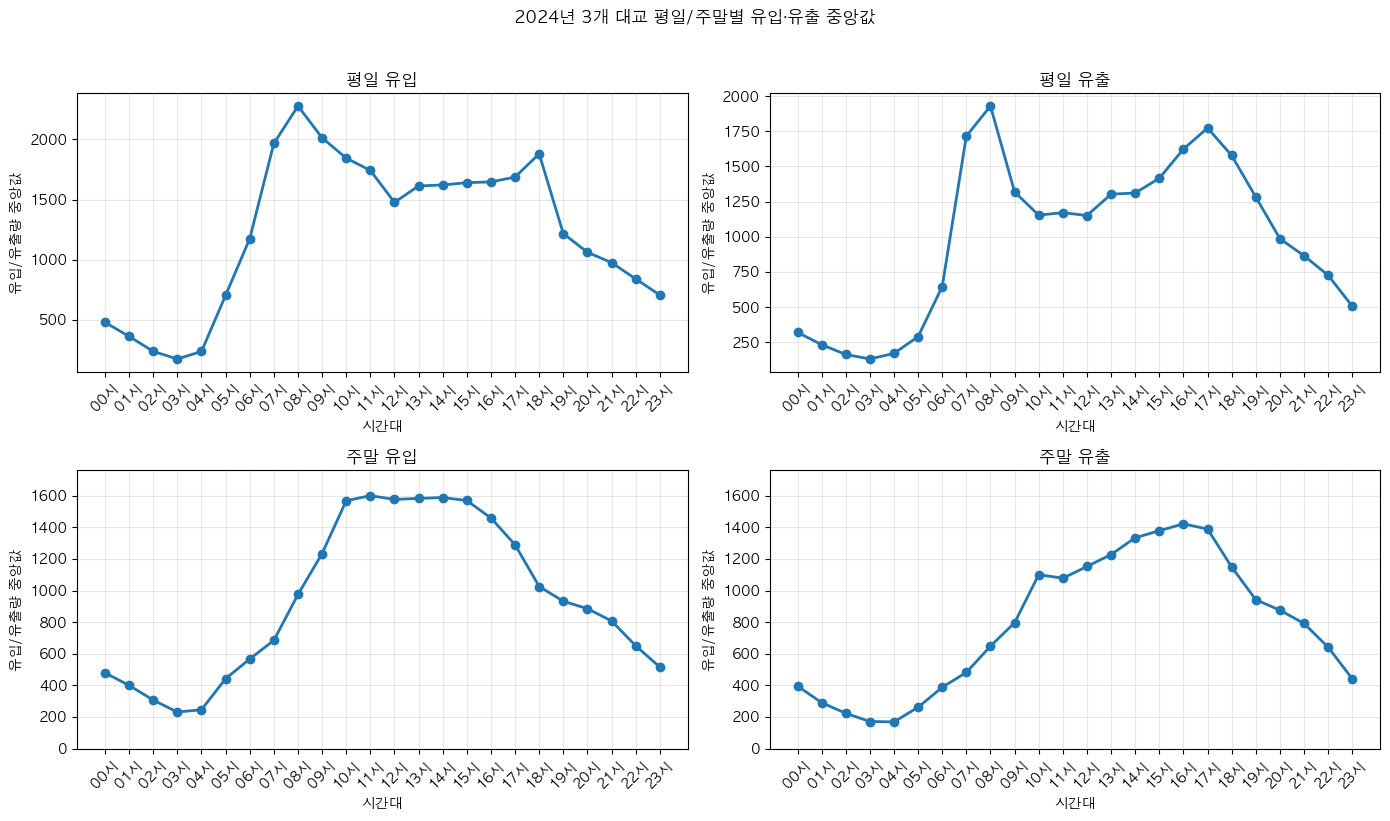

In [10]:
plot_order = [("평일", "유입"), ("평일", "유출"), ("주말", "유입"), ("주말", "유출")]
weekend_max = median_df[median_df["날짜타입"] == "주말"]["중앙값"].max()
weekend_ymax = weekend_max * 1.1 if pd.notna(weekend_max) else None

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)

for ax, (date_type, direction) in zip(axes.flatten(), plot_order):
    subset = median_df[(median_df["날짜타입"] == date_type) & (median_df["방향"] == direction)].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2)
    ax.set_title(f"{date_type} {direction}")
    ax.set_xlabel("시간대")
    ax.set_ylabel("유입/유출량 중앙값")
    ax.set_xticks(range(24))
    ax.set_xticklabels([f"{hour:02d}시" for hour in range(24)], rotation=45)
    if date_type == "주말" and weekend_ymax is not None:
        ax.set_ylim(0, weekend_ymax)
    ax.grid(alpha=0.3)

fig.suptitle(f"{analysis_year}년 3개 대교 평일/주말별 유입·유출 중앙값", y=1.02)
fig.tight_layout()
plt.show()


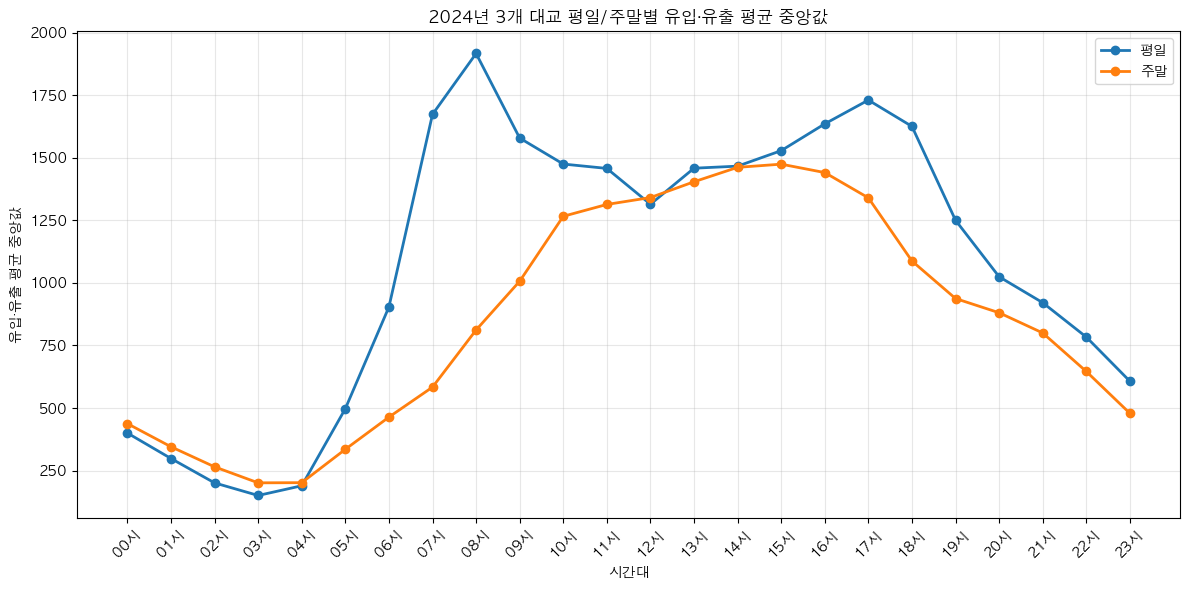

In [11]:
# Combined Weekday/Weekend Summary
combined_station_avg_df = (
    station_avg_df
    .groupby(["지점명", "날짜타입"], as_index=False)[hour_cols]
    .mean()
)

combined_median_df = combined_station_avg_df.melt(
    id_vars=["지점명", "날짜타입"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
combined_median_df["시간_순서"] = combined_median_df["시간"].str.extract(r"(\d+)").astype(int)
combined_median_df = (
    combined_median_df
    .groupby(["날짜타입", "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", "시간_순서"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
for date_type, color in [("평일", "#1f77b4"), ("주말", "#ff7f0e")]:
    subset = combined_median_df[combined_median_df["날짜타입"] == date_type].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2, label=date_type, color=color)

ax.set_title(f"{analysis_year}년 3개 대교 평일/주말별 유입·유출 평균 중앙값")
ax.set_xlabel("시간대")
ax.set_ylabel("유입·유출 평균 중앙값")
ax.set_xticks(range(24))
ax.set_xticklabels([f"{hour:02d}시" for hour in range(24)], rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
